In [3]:
from scipy.io import wavfile
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Read clean speech
sampling_rate, signal = wavfile.read("testing_voice.wav")

if len(signal.shape) > 1:
    signal = signal[:, 0]

signal = signal.astype(float)

C:\Users\Apurbo\AppData\Local\Temp\ipykernel_16316\3606014082.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sampling_rate, signal = wavfile.read("testing_voice.wav")


In [5]:
# (a) Add White Noise at 10 dB SNR
target_snr_db = 10

signal_power = np.mean(signal**2)

noise = np.random.normal(0, 1, len(signal))
noise_power = np.mean(noise**2)

required_noise_power = signal_power / (10**(target_snr_db / 10))

noise = noise * np.sqrt(required_noise_power / noise_power)

noisy_signal = signal + noise

In [6]:
# Compute SNR Before Enhancement
snr_before = 10 * np.log10(np.sum(signal**2) / np.sum((noisy_signal - signal)**2))

# (b) Spectral Subtraction
noisy_fft = np.fft.fft(noisy_signal)
noise_fft = np.fft.fft(noise)

mag_noisy = np.abs(noisy_fft)
phase_noisy = np.angle(noisy_fft)

mag_noise = np.abs(noise_fft)

enhanced_mag = mag_noisy - mag_noise
enhanced_mag = np.maximum(enhanced_mag, 0)

enhanced_fft = enhanced_mag * np.exp(1j * phase_noisy)

enhanced_signal = np.real(np.fft.ifft(enhanced_fft))

In [7]:
# (c) Compute SNR After Enhancement
snr_after = 10 * np.log10(np.sum(signal**2) / np.sum((enhanced_signal - signal)**2))

snr_improvement = snr_after - snr_before

print("SNR Before Enhancement:", round(snr_before, 2), "dB")
print("SNR After Enhancement :", round(snr_after, 2), "dB")
print("SNR Improvement       :", round(snr_improvement, 2), "dB")

SNR Before Enhancement: 10.0 dB
SNR After Enhancement : 22.57 dB
SNR Improvement       : 12.57 dB


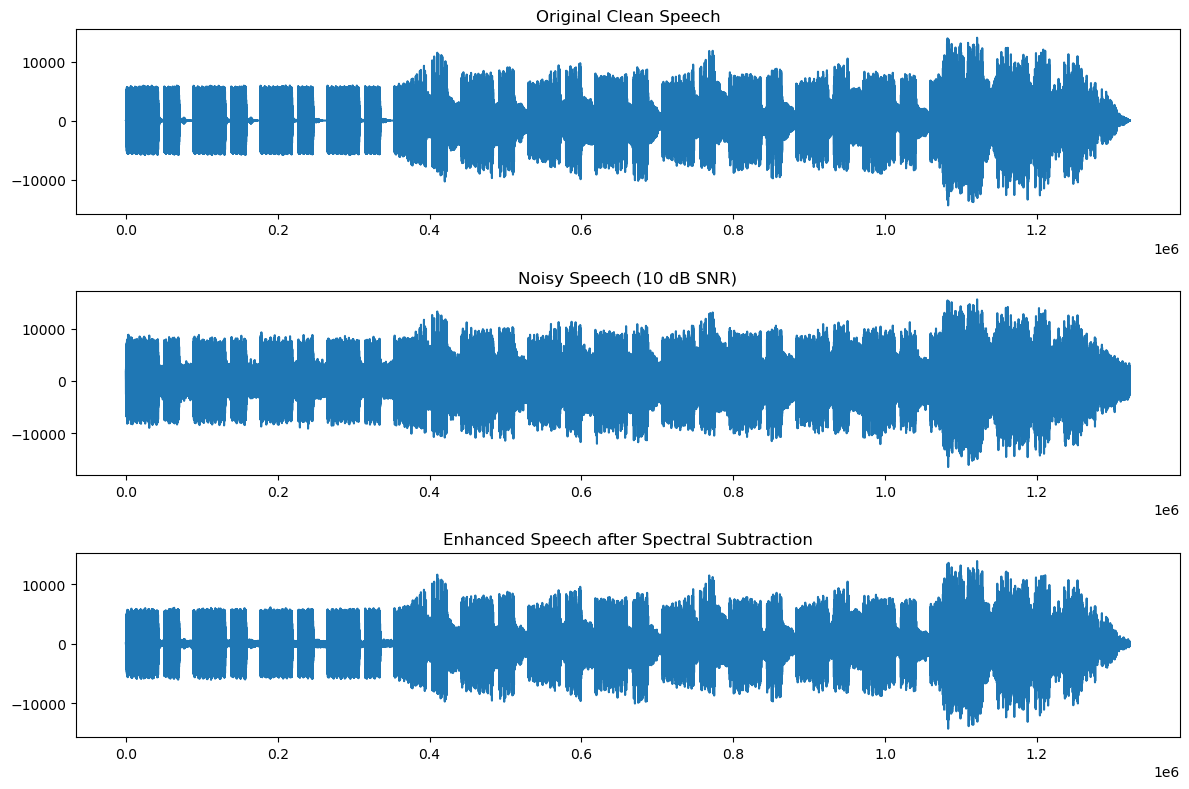

In [8]:
plt.figure(figsize=(12,8))

plt.subplot(3,1,1)
plt.plot(signal)
plt.title("Original Clean Speech")

plt.subplot(3,1,2)
plt.plot(noisy_signal)
plt.title("Noisy Speech (10 dB SNR)")

plt.subplot(3,1,3)
plt.plot(enhanced_signal)
plt.title("Enhanced Speech after Spectral Subtraction")

plt.tight_layout()
plt.show()